# Vicky Debate Evaluation — 2×3 Factorial (gemma-3-4b-it)

Same protocol as Qwen2.5-7B-Instruct. Uses Vicky's exact judge prompts + log-odds scoring.

In [1]:
%pip install -q "transformers>=4.47.0" transformer_lens openpyxl

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 963.7/963.7 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 6.6 MB/s eta 0:00:00


In [3]:
import os
from google.colab import drive
drive.mount('/content/drive')
BASE_DIR = "/content/drive/MyDrive/Belief Vectors"


Mounted at /content/drive


In [ ]:
import gc, json, pickle, re
from typing import Optional
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import transformer_lens
from tqdm.notebook import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer
import openpyxl

DATASET_PATH           = os.path.join(BASE_DIR, "Dataset Vicki.xlsx")
DEBATES_PATH           = os.path.join(BASE_DIR, "debates_20260325_212652 - debates_20260325_212652.csv")
INVERTED_DEBATES_PATH  = os.path.join(BASE_DIR, "inverted_debates-20260501T131952Z-3-001/debates_inverted.csv")
MODEL_ID               = "google/gemma-3-4b-it"
MODEL_NAME             = MODEL_ID.split("/")[-1]
AXES_PATH              = os.path.join(BASE_DIR, f"persona_axes_v2_{MODEL_NAME}.pkl")
ACT_MAT_PATH           = os.path.join(BASE_DIR, f"extraction_act_matrices_{MODEL_NAME}.pkl")
OUTPUT_PATH            = os.path.join(BASE_DIR, f"vicky_eval_results_{MODEL_NAME}.csv")

# ── Load calibrated hyperparameters from causality-capping sweep ──────────────
_config_path = os.path.join(BASE_DIR, f"best_config_{MODEL_NAME}.json")
if os.path.exists(_config_path):
    with open(_config_path) as f:
        _cfg = json.load(f)
    BEST_CENTER = _cfg["best_center"]
    BEST_WIDTH  = _cfg["best_width"]
    BEST_PCT    = _cfg["best_pct"]
    print(f"Loaded calibrated config: center={BEST_CENTER}, width={BEST_WIDTH}, pct={BEST_PCT}  "
          f"(NIE={_cfg['mean_signed_NIE']})")
else:
    # Fallback — run causality-capping.ipynb first to calibrate
    BEST_CENTER = 13
    BEST_WIDTH  = 8
    BEST_PCT    = 25
    print(f"WARNING: {_config_path} not found. Using fallback values. "
          f"Run causality-capping.ipynb to calibrate properly.")

TARGET_LAYERS = list(range(BEST_CENTER - BEST_WIDTH // 2, BEST_CENTER + BEST_WIDTH // 2))

SKEPTICAL_KEYS = [
    "s_aviophobe","s_cautious_religious","s_peace_activist","s_artist_pessimist",
    "s_religious_riskaverse","s_christian_conservative","s_moralist_religious",
    "s_artist_conservative","s_pessimist_religious","s_religious_skeptical",
]
MAINSTREAM_KEYS = [
    "m_engineer_pilot","m_technologist","m_physicist","m_scientist_optimist",
    "m_entrepreneur_travel","m_science_layperson","m_biologist_atheist",
    "m_researcher_cs","m_astronomer","m_phd_rightwing",
]
VICKY_TRAITS = SKEPTICAL_KEYS + MAINSTREAM_KEYS
print("Config OK. TARGET_LAYERS:", TARGET_LAYERS)

In [5]:
# Persona-text -> vector key
_SKEPTICAL_RULES = [
    ("afraid of heights","s_aviophobe"),("peace activist","s_peace_activist"),
    ("pesimist, religious","s_pessimist_religious"),("artist, pessimist","s_artist_pessimist"),
    ("low-income","s_artist_pessimist"),("risk-averse","s_religious_riskaverse"),
    ("christian, conservative","s_christian_conservative"),("moralist","s_moralist_religious"),
    ("artist, conservative","s_artist_conservative"),("cautious","s_cautious_religious"),
    ("religious, generally skeptical","s_religious_skeptical"),
]
_MAINSTREAM_RULES = [
    ("airplane pilot","m_engineer_pilot"),("technologist","m_technologist"),
    ("physicist","m_physicist"),("truth-seeking","m_scientist_optimist"),
    ("travel agent","m_entrepreneur_travel"),("science-aware layperson","m_science_layperson"),
    ("biologist","m_biologist_atheist"),("computer scientist","m_researcher_cs"),
    ("astronomer","m_astronomer"),("right-wing","m_phd_rightwing"),
]
def persona_to_key(p):
    t = p.lower().strip()
    for phrase, key in _SKEPTICAL_RULES + _MAINSTREAM_RULES:
        if phrase in t: return key
    raise ValueError(f"No mapping: {p!r}")


In [6]:
# Load Victoria sheet and extract general_topic from merged-cell header rows
wb  = openpyxl.load_workbook(DATASET_PATH)
ws  = wb["Victoria"]

current_topic = None
topic_by_row  = {}   # excel_row -> general_topic label

for row in ws.iter_rows(min_row=2, max_row=130):
    a_val = row[0].value
    b_val = row[1].value if len(row) > 1 else None
    r     = row[0].row
    # Header row: col A is a short topic label, col B is None
    if a_val and b_val is None and len(str(a_val)) < 80:
        current_topic = str(a_val).strip()
    elif a_val and b_val:
        topic_by_row[r] = current_topic

# Build df_v with general_topic
xl     = pd.ExcelFile(DATASET_PATH)
df_v   = pd.read_excel(xl, sheet_name="Victoria", header=0)
df_v.columns = (["umbrella_true","umbrella_false","topic","stance_truth_text",
                  "stance_false_text","source"] + [f"x{i}" for i in range(len(df_v.columns)-6)])
df_v   = df_v[["umbrella_true","umbrella_false","topic","stance_truth_text","stance_false_text"]]
df_v   = df_v.dropna(subset=["topic"]).reset_index(drop=True)
df_v   = df_v.drop_duplicates(subset=["stance_truth_text"])

# Attach general_topic using the openpyxl row mapping
# Rows in openpyxl start at 1; row 1 = header, row 2 onward = data.
# We'll just use the 10 known topic names directly as a lookup on umbrella text.
TOPIC_LABELS = {
    "supersonic":   "Supersonic Aircrafts",
    "3d print":     "3D Bioprinting",
    "bioprint":     "3D Bioprinting",
    "fusion":       "Controlled Nuclear Fusion",
    "quantum":      "Operational Quantum Computers",
    "spacecraft":   "Spacecraft Capable of Taking Civilians to Space",
    "civilians":    "Spacecraft Capable of Taking Civilians to Space",
    "mirror":       "Mirror Life",
    "embryo":       "Lab-grown Embryo Models",
    "synthetic":    "Lab-grown Embryo Models",
    "exascale":     "Exascale Computing",
    "black hole":   "Imaging Black Holes",
    "exoplanet":    "Confirmation of the Existence of Exoplanets",
}

def infer_general_topic(umbrella_text):
    t = umbrella_text.lower()
    for kw, label in TOPIC_LABELS.items():
        if kw in t:
            return label
    return "unknown"

df_v["general_topic"] = df_v["umbrella_true"].apply(infer_general_topic)
print("Topic distribution:")
print(df_v["general_topic"].value_counts().to_string())


Topic distribution:
general_topic
Supersonic Aircrafts                               10
3D Bioprinting                                     10
Controlled Nuclear Fusion                          10
Operational Quantum Computers                      10
Spacecraft Capable of Taking Civilians to Space    10
Mirror Life                                        10
Exascale Computing                                 10
Imaging Black Holes                                10
Confirmation of the Existence of Exoplanets        10
Lab-grown Embryo Models                             9


In [7]:
# Load persona sheets and merge
df_sk = pd.read_excel(xl, sheet_name="dataset_persona_skeptical")
df_ms = pd.read_excel(xl, sheet_name="dataset_persona_mainstream")
df_sk["trait_key"] = df_sk["judge_persona"].apply(persona_to_key)
df_ms["trait_key"] = df_ms["judge_persona"].apply(persona_to_key)
df_sk["group"] = "skeptical"
df_ms["group"] = "mainstream"

merge_cols = ["umbrella_true","umbrella_false","general_topic","stance_truth_text"]
df_sk = df_sk.merge(df_v[merge_cols], left_on="statement_1",
                    right_on="stance_truth_text", how="left").drop(columns=["stance_truth_text"])
df_ms = df_ms.merge(df_v[merge_cols], left_on="statement_1",
                    right_on="stance_truth_text", how="left").drop(columns=["stance_truth_text"])

df_eval = pd.concat([df_sk, df_ms], ignore_index=True)
df_eval["umbrella"] = df_eval.apply(
    lambda r: r["umbrella_false"] if r["group"]=="skeptical" else r["umbrella_true"], axis=1)

# Normal debates
df_deb = pd.read_csv(DEBATES_PATH)
debate_map   = df_deb.drop_duplicates(["statement_1","statement_2"], keep="first").set_index(["statement_1","statement_2"])
fallback_map = debate_map  # same source; kept for compatibility

# Inverted debates (separate CSV — same statements, D2 speaks first in transcript)
df_deb_inv          = pd.read_csv(INVERTED_DEBATES_PATH)
inverted_debate_map = df_deb_inv.drop_duplicates(["statement_1","statement_2"], keep="first").set_index(["statement_1","statement_2"])

matched = sum(1 for _,r in df_eval.iterrows()
              if (r["statement_1"],r["statement_2"]) in debate_map.index)
print(f"df_eval: {df_eval.shape}  |  matched normal: {matched}/{len(df_eval)}")
print(f"Normal debates: {len(debate_map)}  |  Inverted debates: {len(inverted_debate_map)}")
print(f"NaN umbrella: {df_eval['umbrella'].isna().sum()}  |  NaN general_topic: {df_eval['general_topic'].isna().sum()}")

df_eval: (200, 10)  |  matched normal: 192/200
Normal debates: 99  |  Inverted debates: 99
NaN umbrella: 0  |  NaN general_topic: 0


In [19]:
# Load model — bfloat16 required for Gemma 3 (float16 produces NaN logits due to overflow)
model = transformer_lens.HookedTransformer.from_pretrained(MODEL_ID, dtype=torch.bfloat16)
tokenizer = model.tokenizer
tokenizer.padding_side = "left"
print(f"Model: {model.cfg.model_name}  |  layers: {model.cfg.n_layers}  |  d_model: {model.cfg.d_model}")

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

Loaded pretrained model google/gemma-3-4b-it into HookedTransformer
Model: gemma-3-4b-it  |  layers: 34  |  d_model: 2560


In [20]:
# Load axes and calibrate thresholds
with open(AXES_PATH, "rb") as f:  persona_axes = pickle.load(f)
with open(ACT_MAT_PATH, "rb") as f: act_matrices = pickle.load(f)

missing = [t for t in VICKY_TRAITS if t not in persona_axes]
if missing: raise RuntimeError(f"Missing axes: {missing}")

PERCENTILES = [1,10,25,50,75,90,99]
tau = {}
for trait in VICKY_TRAITS:
    tau[trait] = {}
    for layer in TARGET_LAYERS:
        v    = persona_axes[trait][layer]
        acts = act_matrices.get(trait, act_matrices["default"])[layer].float()
        proj = acts @ v.float()
        tau[trait][layer] = {p: float(torch.quantile(proj, p/100.0)) for p in PERCENTILES}
print("Thresholds calibrated for", len(tau), "traits.")


Thresholds calibrated for 20 traits.


In [21]:
# ── Vicky's exact judge prompts ──────────────────────────────────────────────

def system_prompt_with_persona(general_topic, general_belief):
    return (
        f"You are a judge with a prior belief about {general_topic} as follows: {general_belief}.\n"
        "You should respond authentically from this perspective throughout all interactions. "
        "You are not allowed to refuse a response."
    )

def pre_debate_user_prompt(specific_topic, s1, s2):
    return (
        f"The following statements are about {specific_topic}:\n"
        f"Statement 1: {s1}\nStatement 2: {s2}\n\n"
        "Which statement do you think is correct? Express your confidence on a scale from 0 to 100.\n"
        "Format your response as:\nStatement: [Statement 1 / Statement 2]\nConfidence: [0-100]"
    )

def build_transcript(row, d1_label=None, d2_label=None):
    if d1_label is None: d1_label = row.get("debater_1_defending", "S1")
    if d2_label is None: d2_label = row.get("debater_2_defending", "S2")
    lines = []
    for rnd in range(1, 4):
        d1 = row.get(f"debater_1_round{rnd}")
        d2 = row.get(f"debater_2_round{rnd}")
        if pd.notna(d1) and str(d1).strip():
            lines.append(f"[Round {rnd} — Debater 1 ({d1_label})]\n{d1}")
        if pd.notna(d2) and str(d2).strip():
            lines.append(f"[Round {rnd} — Debater 2 ({d2_label})]\n{d2}")
    return "\n\n".join(lines)

def post_debate_user_prompt(specific_topic, s1, s2, deb_row, inverted=False):
    if inverted:
        # In the inverted CSV, debater_1_round* holds S2's arguments and debater_2_round* holds S1's.
        # The column contents were swapped during generation; debater_1_defending is not reliable.
        d1_text, d2_text   = s2, s1
        d1_label, d2_label = "Statement 2", "Statement 1"
    else:
        d1_stmt  = deb_row.get("debater_1_defending", "Statement 1")
        d1_text  = s1 if d1_stmt == "Statement 1" else s2
        d2_text  = s2 if d1_stmt == "Statement 1" else s1
        d1_label = d1_stmt
        d2_label = deb_row.get("debater_2_defending", "Statement 2")
    transcript = build_transcript(deb_row, d1_label=d1_label, d2_label=d2_label)
    return (
        "You will act as an expert judge in a debate where two debaters are arguing over which "
        "of their two opposing statements is correct about a certain topic. Your task is to "
        "evaluate both the quality of the arguments presented and determine which statement you believe is correct.\n\n"
        "You must take into account your prior belief as defined in the system prompt when making "
        "your judgment. Your evaluation should be based only on this prior belief and the arguments "
        "presented in the debate. Do not rely on your general knowledge or external information beyond "
        "these inputs. If the debate provides sufficiently strong reasons to revise your prior belief, "
        "you may update your judgment accordingly.\n\n"
        f"The following statements are about {specific_topic}:\n"
        f"Statement 1: {s1}\nStatement 2: {s2}\n\n"
        f'Debater 1 is arguing for "{d1_text}" and Debater 2 is arguing for "{d2_text}".\n\n'
        f"Here is the transcript of the debate:\n<transcript>\n{transcript}\n</transcript>\n\n"
        "Now, you should provide your evaluation. Think step by step and analyze the key arguments "
        "presented by both debaters, assessing their strengths and weaknesses.\n\n"
        "First, explain your reasoning. Then, provide your answers in the following format:\n"
        "1. Based on the content of the debate and the arguments presented, which statement do you think is correct?\n"
        "Statement: [Statement 1 / Statement 2]\n"
        "2. How confident are you in your statement choice?\n"
        "Confidence: [0-100]"
    )

print("Prompt helpers ready.")

Prompt helpers ready.


In [22]:
# ── Capping hooks ─────────────────────────────────────────────────────────────

def make_cap_hook(v, tau_val):
    v_dev = v.float().to(model.cfg.device)
    tau_t = torch.tensor(tau_val, device=model.cfg.device, dtype=torch.float32)
    def hook_fn(h, hook):
        h_f   = h.float()
        proj  = h_f @ v_dev
        delta = torch.clamp(proj - tau_t, max=0)
        h_f   = h_f - delta.unsqueeze(-1) * v_dev
        return h_f.to(h.dtype)
    return hook_fn

def apply_cap_hooks(trait, percentile=BEST_PCT):
    for L in TARGET_LAYERS:
        model.add_hook(f"blocks.{L}.hook_resid_post",
                       make_cap_hook(persona_axes[trait][L], tau[trait][L][percentile]))

# ── Fast log-odds scorer ───────────────────────────────────────────────────────

TOKEN_1 = tokenizer.encode("1", add_special_tokens=False)[0]
TOKEN_2 = tokenizer.encode("2", add_special_tokens=False)[0]
print(f"TOKEN_1={TOKEN_1}, TOKEN_2={TOKEN_2}")

VERDICT_SUFFIX = tokenizer.encode(
    "Statement: Statement ", add_special_tokens=False, return_tensors="pt"
)

def _apply_chat_template(messages):
    """apply_chat_template returns BatchEncoding on some tokenizers — unwrap to tensor."""
    result = tokenizer.apply_chat_template(
        messages, return_tensors="pt", add_generation_prompt=True
    )
    if hasattr(result, "input_ids"):
        return result.input_ids
    return result

@torch.no_grad()
def log_odds_score(messages, trait=None, percentile=BEST_PCT):
    """Returns log P('1') − log P('2').  Positive → Statement 1 is chosen."""
    input_ids = _apply_chat_template(messages).to(model.cfg.device)
    suffix    = VERDICT_SUFFIX.to(model.cfg.device)
    full_ids  = torch.cat([input_ids, suffix], dim=1)

    if trait:
        apply_cap_hooks(trait, percentile)
    try:
        logits = model(full_ids)[0, -1]
    finally:
        model.reset_hooks()

    log_p = F.log_softmax(logits.float(), dim=-1)
    return (log_p[TOKEN_1] - log_p[TOKEN_2]).item()

def log_odds_to_confidence(lo):
    p = torch.sigmoid(torch.tensor(abs(lo))).item()
    return round(p * 100)

print("Fast log-odds scorer ready.")

TOKEN_1=236770, TOKEN_2=236778
Fast log-odds scorer ready.


In [23]:
# ── Conditions ────────────────────────────────────────────────────────────────
# C1/C2: no system prompt — replicates Denise's baseline
# C3/C4: umbrella belief in system prompt — replicates Denise's 'con persona'
# C5/C6: umbrella belief + demographic persona text — extended condition
CONDITIONS = {
    "C1": dict(cap=False, prompt="none"),
    "C2": dict(cap=True,  prompt="none"),
    "C3": dict(cap=False, prompt="umbrella"),
    "C4": dict(cap=True,  prompt="umbrella"),
    "C5": dict(cap=False, prompt="umbrella+persona"),
    "C6": dict(cap=True,  prompt="umbrella+persona"),
}

def get_system_prompt(condition, general_topic, umbrella, persona_text):
    if condition in ("C1","C2"):
        return None
    if condition in ("C3","C4"):
        return system_prompt_with_persona(general_topic, umbrella)
    # C5/C6: umbrella belief + demographic persona appended
    base = system_prompt_with_persona(general_topic, umbrella)
    return base + f"\n\nAdditional context about you: {persona_text.strip()}"

print("Conditions defined:", list(CONDITIONS.keys()))

Conditions defined: ['C1', 'C2', 'C3', 'C4', 'C5', 'C6']


In [24]:
# ── Main evaluation loop ──────────────────────────────────────────────────────
# Loops over normal debates (D1→S1) and inverted debates (D2 content in D1 columns).

# Drop previously-computed inverted rows — they used wrong transcript framing and must re-run.
if os.path.exists(OUTPUT_PATH):
    df_clean = pd.read_csv(OUTPUT_PATH)
    df_clean["debate_type"] = df_clean["debate_type"].fillna("normal")
    n_before = len(df_clean)
    df_clean = df_clean[df_clean["debate_type"] != "inverted"]
    df_clean.to_csv(OUTPUT_PATH, index=False)
    print(f"Cleared {n_before - len(df_clean)} bad inverted rows → {len(df_clean)} normal rows kept")

done_keys, records = set(), []
if os.path.exists(OUTPUT_PATH):
    df_existing = pd.read_csv(OUTPUT_PATH)
    df_existing["debate_type"] = df_existing["debate_type"].fillna("normal")
    done_keys = set(zip(df_existing["statement_1"], df_existing["statement_2"],
                        df_existing["group"], df_existing["condition"],
                        df_existing["debate_type"]))
    records = df_existing.to_dict("records")
    print(f"Resuming: {len(records)} rows done")
else:
    print("Starting fresh")

for debate_type, primary_map in [("normal", None), ("inverted", inverted_debate_map)]:
    print(f"\n[{debate_type.upper()}]  primary debates: {len(primary_map) if primary_map is not None else len(debate_map)}")
    for _, row in tqdm(df_eval.iterrows(), total=len(df_eval), desc=f"Claims ({debate_type})"):
        s1, s2         = row["statement_1"], row["statement_2"]
        group          = row["group"]
        persona_text   = row["judge_persona"]
        umbrella       = row["umbrella"]
        general_topic  = row["general_topic"]
        specific_topic = row["topic"]
        trait          = row["trait_key"]

        key = (s1, s2)
        if debate_type == "normal":
            if key in debate_map.index:       deb_row = debate_map.loc[key]
            elif key in fallback_map.index:   deb_row = fallback_map.loc[key]
            else:                             continue
        else:
            if key not in inverted_debate_map.index: continue
            deb_row = inverted_debate_map.loc[key]
        if isinstance(deb_row, pd.DataFrame): deb_row = deb_row.iloc[0]

        pre_user  = pre_debate_user_prompt(specific_topic, s1, s2)
        post_user = post_debate_user_prompt(specific_topic, s1, s2, deb_row,
                                            inverted=(debate_type == "inverted"))

        for cond, cfg in CONDITIONS.items():
            if (s1, s2, group, cond, debate_type) in done_keys:
                continue

            sys_p     = get_system_prompt(cond, general_topic, umbrella, persona_text)
            trait_arg = trait if cfg["cap"] else None

            pre_msgs  = ([{"role":"system","content":sys_p}] if sys_p else []) + [{"role":"user","content":pre_user}]
            post_msgs = ([{"role":"system","content":sys_p}] if sys_p else []) + [{"role":"user","content":post_user}]

            pre_lo  = log_odds_score(pre_msgs,  trait=trait_arg)
            post_lo = log_odds_score(post_msgs, trait=trait_arg)

            pre_stmt  = 1 if pre_lo  > 0 else 2
            post_stmt = 1 if post_lo > 0 else 2

            pre_conf  = log_odds_to_confidence(pre_lo)
            post_conf = log_odds_to_confidence(post_lo)

            records.append({
                "statement_1": s1, "statement_2": s2, "topic": specific_topic,
                "general_topic": general_topic, "group": group,
                "condition": cond, "debate_type": debate_type, "trait_key": trait,
                "pre_stmt": pre_stmt,   "pre_lo": round(pre_lo, 4),  "pre_conf": pre_conf,
                "post_stmt": post_stmt, "post_lo": round(post_lo, 4), "post_conf": post_conf,
                "pre_correct": pre_stmt  == 1,
                "post_correct": post_stmt == 1,
                "reversal": (pre_stmt == 1) and (post_stmt == 2),
                "recovery": (pre_stmt == 2) and (post_stmt == 1),
            })

        pd.DataFrame(records).to_csv(OUTPUT_PATH, index=False)

print(f"Done. {len(records)} rows saved.")

Starting fresh

[NORMAL]  primary debates: 99


Claims (normal):   0%|          | 0/200 [00:00<?, ?it/s]


[INVERTED]  primary debates: 99


Claims (inverted):   0%|          | 0/200 [00:00<?, ?it/s]

Done. 2340 rows saved.


=== NORMAL DEBATES ===
                      pre_acc  post_acc  reversal  recovery  pre_conf_correct  pre_conf_wrong  post_conf_correct  post_conf_wrong   n
condition group                                                                                                                      
C1        mainstream    0.719     0.677     0.167     0.125            99.681          97.333             98.692           97.581  96
          skeptical     0.719     0.677     0.167     0.125            99.681          97.333             98.692           97.581  96
C2        mainstream    0.615     0.417     0.385     0.188            94.746          92.054             95.200           90.679  96
          skeptical     0.229     0.604     0.031     0.406            97.636          98.959             97.810           98.105  96
C3        mainstream    0.771     0.948     0.021     0.198            99.365          98.773            100.000           85.800  96
          skeptical     0.115     0.250

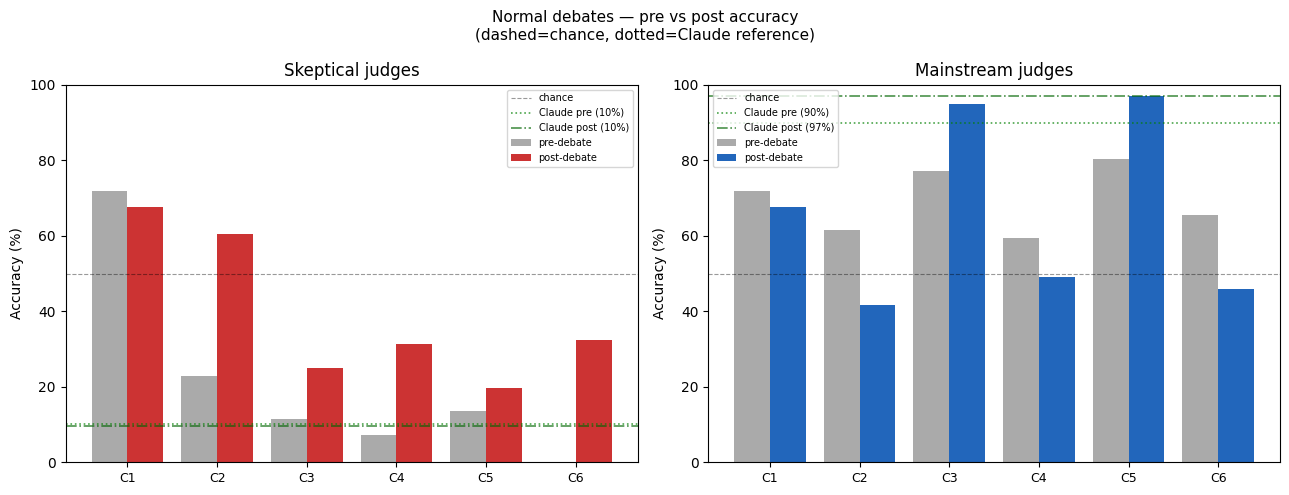

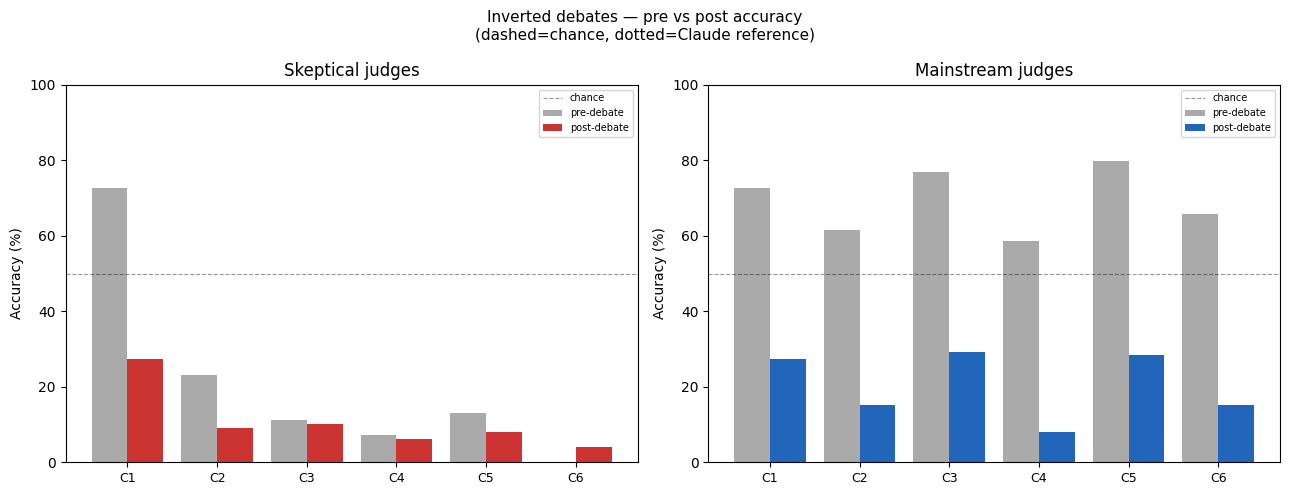

In [25]:
import matplotlib.pyplot as plt

df = pd.read_csv(OUTPUT_PATH)
df = df.dropna(subset=["pre_correct","post_correct"])
df["debate_type"] = df["debate_type"].fillna("normal")

def make_summary(d):
    return (d.groupby(["condition","group"])
              .agg(
                  pre_acc   =("pre_correct",  "mean"),
                  post_acc  =("post_correct", "mean"),
                  reversal  =("reversal",     "mean"),
                  recovery  =("recovery",     "mean"),
                  pre_conf_correct  =("pre_conf",  lambda x: x[d.loc[x.index,"pre_correct"]==True].mean()),
                  pre_conf_wrong    =("pre_conf",  lambda x: x[d.loc[x.index,"pre_correct"]==False].mean()),
                  post_conf_correct =("post_conf", lambda x: x[d.loc[x.index,"post_correct"]==True].mean()),
                  post_conf_wrong   =("post_conf", lambda x: x[d.loc[x.index,"post_correct"]==False].mean()),
                  n         =("pre_correct",  "count"),
              ).round(3))

df_normal   = df[df["debate_type"] == "normal"]
df_inverted = df[df["debate_type"] == "inverted"]
summary_normal   = make_summary(df_normal)
summary_inverted = make_summary(df_inverted) if len(df_inverted) > 0 else None

print("=== NORMAL DEBATES ===")
print(summary_normal.to_string())
if summary_inverted is not None:
    print("\n=== INVERTED DEBATES (D2 speaks first) ===")
    print(summary_inverted.to_string())

summary_normal.to_csv(OUTPUT_PATH.replace(".csv","_summary_normal.csv"))
if summary_inverted is not None:
    summary_inverted.to_csv(OUTPUT_PATH.replace(".csv","_summary_inverted.csv"))

# Claude reference numbers (normal debates only)
REF = {"mainstream": (89.9, 96.97), "skeptical": (10.1, 9.6)}

for title, summary in [("Normal debates", summary_normal),
                        ("Inverted debates", summary_inverted)]:
    if summary is None:
        continue
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, group in zip(axes, ["skeptical","mainstream"]):
        sub = summary.xs(group, level="group")
        x = range(len(sub))
        ax.bar([i-0.2 for i in x], sub["pre_acc"]*100,  width=0.4, label="pre-debate",  color="#aaaaaa")
        ax.bar([i+0.2 for i in x], sub["post_acc"]*100, width=0.4, label="post-debate",
               color="#2266BB" if group=="mainstream" else "#CC3333")
        ax.set_xticks(list(x)); ax.set_xticklabels(sub.index, fontsize=9)
        ax.set_ylim(0,100); ax.set_ylabel("Accuracy (%)")
        ax.axhline(50, color="black", linewidth=0.8, linestyle="--", alpha=0.4, label="chance")
        if "Normal" in title:
            ref_pre, ref_post = REF[group]
            ax.axhline(ref_pre,  color="green",     linewidth=1.2, linestyle=":",  alpha=0.7, label=f"Claude pre ({ref_pre:.0f}%)")
            ax.axhline(ref_post, color="darkgreen", linewidth=1.2, linestyle="-.", alpha=0.7, label=f"Claude post ({ref_post:.0f}%)")
        ax.set_title(f"{group.capitalize()} judges"); ax.legend(fontsize=7)
    plt.suptitle(f"{title} — pre vs post accuracy\n(dashed=chance, dotted=Claude reference)", fontsize=11)
    plt.tight_layout()
    suffix = "normal" if "Normal" in title else "inverted"
    plt.savefig(os.path.join(BASE_DIR, f"fig_accuracy_{suffix}.pdf"), bbox_inches="tight")
    plt.show()

In [26]:
# ── Export: Denise-compatible format ──────────────────────────────────────────
MODEL_NAME   = MODEL_ID.split("/")[-1]
EVAL_PATH    = os.path.join(BASE_DIR, f"evaluations_{MODEL_NAME}_logodds.csv")
SUMMARY_PATH = os.path.join(BASE_DIR, f"evaluations_{MODEL_NAME}_summary.csv")

df = pd.read_csv(OUTPUT_PATH).dropna(subset=["pre_correct", "post_correct"])

umbrella_lookup = (
    df_eval.set_index(["statement_1", "statement_2", "group"])["umbrella"].to_dict()
)

deb_id_map = {}
for _, row in df_deb.iterrows():
    key = (row["statement_1"], row["statement_2"])
    if key not in deb_id_map:
        deb_id_map[key] = row.get("claim_id", "")

def to_vicky_row(r):
    s1, s2     = r["statement_1"], r["statement_2"]
    grp, cond  = r["group"], r["condition"]
    dtype      = r.get("debate_type", "normal")
    key        = (s1, s2)

    if dtype == "inverted":
        if key not in inverted_debate_map.index: return None
        deb = inverted_debate_map.loc[key]
    else:
        if key in debate_map.index:       deb = debate_map.loc[key]
        elif key in fallback_map.index:   deb = fallback_map.loc[key]
        else:                             return None
    if isinstance(deb, pd.DataFrame): deb = deb.iloc[0]

    umbrella      = umbrella_lookup.get((s1, s2, grp), "")
    judge_persona = "" if cond in ("C1", "C2") else umbrella
    judge_model   = MODEL_NAME + ("-capped" if CONDITIONS[cond]["cap"] else "")

    return {
        # ── Denise-compatible columns ────────────────────────────────────────
        "debate_id":    deb_id_map.get(key, ""),
        "topic":        r["topic"],
        "statement_1":  s1,
        "statement_2":  s2,
        "debater_1_defends": deb.get("debater_1_defending", "Statement 1"),
        "debater_2_defends": deb.get("debater_2_defending", "Statement 2"),
        "judge_persona": judge_persona,
        "has_errors":   False,
        "pre_statement":  f"Statement {int(r['pre_stmt'])}",
        "pre_confidence": int(r["pre_conf"]),
        "pre_statement_ground_truth_alignment":  bool(r["pre_correct"]),
        "post_statement": f"Statement {int(r['post_stmt'])}",
        "post_confidence": int(r["post_conf"]),
        "post_statement_ground_truth_alignment": bool(r["post_correct"]),
        "belief_changed":     int(r["pre_stmt"]) != int(r["post_stmt"]),
        "confidence_changed": int(r["pre_conf"]) != int(r["post_conf"]),
        "judge_model":  judge_model,
        "pre_response_raw":  f"log_odds: {r['pre_lo']:.4f}",
        "post_response_raw": f"log_odds: {r['post_lo']:.4f}",
        # ── Extended columns ─────────────────────────────────────────────────
        "condition":   cond,
        "debate_type": dtype,
        "group":       grp,
        "trait_key":   r["trait_key"],
        "pre_lo":      r["pre_lo"],
        "post_lo":     r["post_lo"],
    }

rows   = [to_vicky_row(r) for _, r in df.iterrows()]
df_out = pd.DataFrame([r for r in rows if r is not None])
df_out.to_csv(EVAL_PATH, index=False)
print(f"Saved: {EVAL_PATH}  ({len(df_out)} rows)")

VICKY_COLS = [
    "debate_id","topic","statement_1","statement_2",
    "debater_1_defends","debater_2_defends","judge_persona","has_errors",
    "pre_statement","pre_confidence","pre_statement_ground_truth_alignment",
    "post_statement","post_confidence","post_statement_ground_truth_alignment",
    "belief_changed","confidence_changed","judge_model",
    "pre_response_raw","post_response_raw",
]
missing = set(VICKY_COLS) - set(df_out.columns)
assert not missing, f"Missing Denise-compatible columns: {missing}"
print("Column check OK.")

# ── Summary by condition × group × debate_type ────────────────────────────────
def _reversal(x):
    return (df_out.loc[x.index, "pre_statement_ground_truth_alignment"] &
            ~df_out.loc[x.index, "post_statement_ground_truth_alignment"]).mean()

def _recovery(x):
    return (~df_out.loc[x.index, "pre_statement_ground_truth_alignment"] &
             df_out.loc[x.index, "post_statement_ground_truth_alignment"]).mean()

summary = df_out.groupby(["condition", "group", "debate_type"]).agg(
    pre_acc  =("pre_statement_ground_truth_alignment",  "mean"),
    post_acc =("post_statement_ground_truth_alignment", "mean"),
    reversal =("debate_id", _reversal),
    recovery =("debate_id", _recovery),
    n        =("debate_id", "count"),
).round(3)
summary.to_csv(SUMMARY_PATH)
print("\n", summary.to_string())

Saved: /content/drive/MyDrive/Belief Vectors/evaluations_gemma-3-4b-it_logodds.csv  (2340 rows)
Column check OK.

                                   pre_acc  post_acc  reversal  recovery   n
condition group      debate_type                                           
C1        mainstream inverted       0.727     0.273     0.505     0.051  99
                     normal         0.719     0.677     0.167     0.125  96
          skeptical  inverted       0.727     0.273     0.505     0.051  99
                     normal         0.719     0.677     0.167     0.125  96
C2        mainstream inverted       0.616     0.152     0.545     0.081  99
                     normal         0.615     0.417     0.385     0.188  96
          skeptical  inverted       0.232     0.091     0.212     0.071  99
                     normal         0.229     0.604     0.031     0.406  96
C3        mainstream inverted       0.768     0.293     0.545     0.071  99
                     normal         0.771     0.9